# アクレ州マデイラ川上流西部のS-1〜S-5パイプライン

このノートブックでは、アクレ州マデイラ川上流西部の水場系トポニムを抽出し、古河道候補地点を特定するパイプラインを実装します。

## パイプラインの概要

1. **S-1**: 対象地域のBBox定義
2. **S-2**: 水場系トポニムの抽出（BNGB API、OpenStreetMap）
3. **S-3**: クレンジング & タイプ付け
4. **S-4**: 現河道との距離計算
5. **S-5**: "川が無いのに川名が残る"ポイント抽出

## 必要なライブラリのインポート

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point, box

# プロジェクトのルートディレクトリをパスに追加
sys.path.append(os.path.abspath('../src'))

# 自作パッケージのインポート
from tamagawa_to_z.harmonizer import (
    make_bbox_gdf, process_toponyms,
    attach_distance, water_occurrence, filter_candidates, score_candidates
)
from tamagawa_to_z.harmonizer.preprocess import extract_acre_toponyms_pyrosm

## データディレクトリの設定

In [2]:
# データディレクトリの作成
os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../data/interim", exist_ok=True)

# 入力データのパス
RIVERS_PATH = "../data/raw/hydrorivers_sahydrorivers_sa/HydroRIVERS_v10_sa.shp"
GSW_PATH = "../data/raw/GSW_occurrence/occurrence_70W_10Sv1_4_2021.tif"
PBF_PATH = "../data/raw/osm/norte-latest.osm.pbf"

# 出力データのパス
OUTPUT_PATH = "../data/interim/acre_candidates.parquet"

# 入力データの存在確認
if not os.path.exists(RIVERS_PATH):
    print(f"警告: {RIVERS_PATH} が見つかりません。")
    print("HydroRIVERS_SA.shp を data/raw/ ディレクトリに配置してください。")
    print("ダウンロード先: https://www.hydrosheds.org/products/hydrorivers")

if not os.path.exists(GSW_PATH):
    print(f"警告: {GSW_PATH} が見つかりません。")
    print("GSW_occurrence.tif を data/raw/ ディレクトリに配置してください。")
    print("ダウンロード先: https://global-surface-water.appspot.com/download")

if not os.path.exists(PBF_PATH):
    print(f"警告: {PBF_PATH} が見つかりません。")
    print("OpenStreetMap PBFファイルを data/raw/osm/ ディレクトリに配置してください。")
    print("ダウンロード先: https://download.geofabrik.de/south-america/brazil.html")

## S-1: 対象地域のBBox定義

アクレ州マデイラ川上流西部の境界を定義します。

ブラジル全土地図: OpenStreetMapから背景地図を読み込み中...
✓ OpenStreetMapの背景地図を正常に読み込みました


/var/folders/l0/wgl5khrn3c9dp93hhw70vlm40000gn/T/ipykernel_34720/198668908.py:95: UserWarning: Glyph 32076 (\N{CJK UNIFIED IDEOGRAPH-7D4C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l0/wgl5khrn3c9dp93hhw70vlm40000gn/T/ipykernel_34720/198668908.py:95: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l0/wgl5khrn3c9dp93hhw70vlm40000gn/T/ipykernel_34720/198668908.py:95: UserWarning: Glyph 32239 (\N{CJK UNIFIED IDEOGRAPH-7DEF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l0/wgl5khrn3c9dp93hhw70vlm40000gn/T/ipykernel_34720/198668908.py:95: UserWarning: Glyph 12502 (\N{KATAKANA LETTER BU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l0/wgl5khrn3c9dp93hhw70vlm40000gn/T/ipykernel_34720/198668908.py:95: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l0/wgl5khrn3c9dp93hhw70vlm40

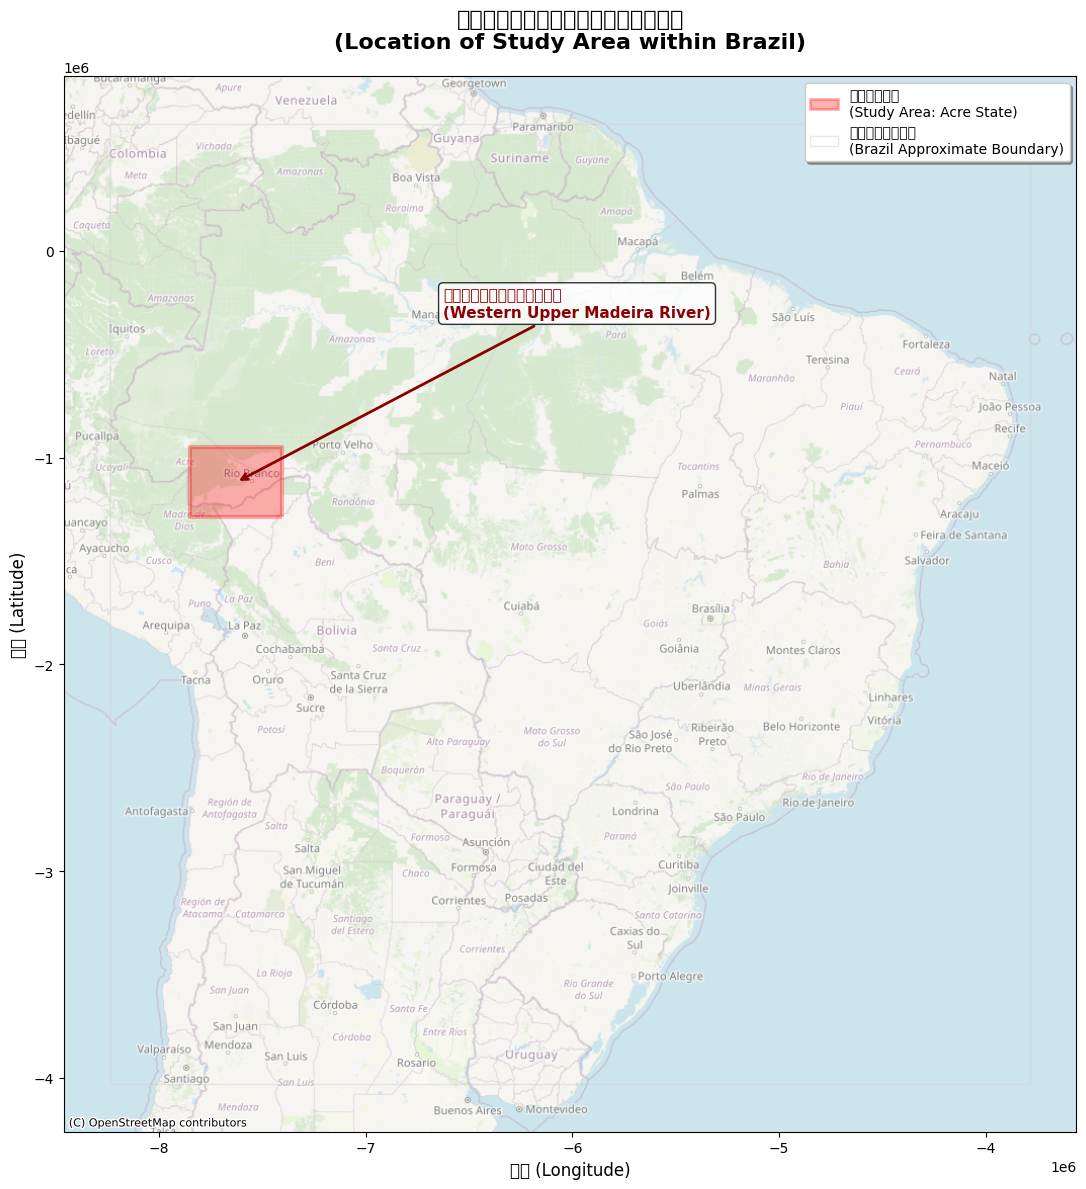


🌍 ブラジル全土における対象領域の位置情報
📍 研究対象領域: アクレ州マデイラ川上流西部
🗺️  経度: -70.5° ～ -66.5° W
🗺️  緯度: 11.5° ～ 8.5° S
🏞️  地理的特徴: アマゾン川流域、ペルー国境付近
🌊 主要河川: マデイラ川（アマゾン川の主要支流）
🌿 生態系: アマゾン熱帯雨林


In [3]:
# ブラジル全土での対象領域の位置確認
import contextily as ctx
from matplotlib.patches import Patch

# BBoxの作成
bbox_gdf = make_bbox_gdf()
bbox = bbox_gdf.geometry.iloc[0]

# ブラジル全土の概略境界を定義
brazil_bounds = {
    'west': -74.0,   # 西端（アクレ州西部）
    'east': -34.0,   # 東端（大西洋沿岸）
    'south': -34.0,  # 南端（リオグランデ・ド・スル州）
    'north': 5.5     # 北端（ロライマ州）
}

# ブラジル全土のGeoDataFrameを作成
from shapely.geometry import box
brazil_bbox = box(brazil_bounds['west'], brazil_bounds['south'], 
                  brazil_bounds['east'], brazil_bounds['north'])
brazil_gdf = gpd.GeoDataFrame({"id": [1]}, geometry=[brazil_bbox], crs="EPSG:4326")

# 可視化（ブラジル全土）
fig, ax = plt.subplots(figsize=(14, 12))

# Web Mercator投影に変換
brazil_gdf_mercator = brazil_gdf.to_crs(epsg=3857)
bbox_gdf_mercator = bbox_gdf.to_crs(epsg=3857)

# ブラジル全土の枠をプロット（薄いグレー）
brazil_gdf_mercator.plot(ax=ax, color='none', edgecolor='lightgray', linewidth=1, alpha=0.5)

# 対象領域をプロット（赤色で強調）
bbox_gdf_mercator.plot(ax=ax, color='red', alpha=0.3, edgecolor='red', linewidth=3)

# 背景地図を追加
basemap_loaded = False
try:
    basemap_sources = [
        ("OpenStreetMap", ctx.providers.OpenStreetMap.Mapnik),
        ("CartoDB Positron", ctx.providers.CartoDB.Positron),
    ]
except AttributeError:
    basemap_sources = [
        ("OpenStreetMap", ctx.sources.OSM_A),
        ("CartoDB", ctx.sources.CARTODB_POSITRON),
    ]

for name, source in basemap_sources:
    try:
        print(f"ブラジル全土地図: {name}から背景地図を読み込み中...")
        ctx.add_basemap(ax, crs=brazil_gdf_mercator.crs, source=source, alpha=0.6)
        print(f"✓ {name}の背景地図を正常に読み込みました")
        basemap_loaded = True
        break
    except Exception as e:
        print(f"✗ {name}の読み込みに失敗: {e}")
        continue

# 背景地図が読み込めない場合のフォールバック
if not basemap_loaded:
    print("背景地図の読み込みに失敗しました。基本的な地理的コンテキストを追加します。")
    ax.set_facecolor('#f0f8ff')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# タイトルと軸ラベル
ax.set_title('ブラジル全土における対象領域の位置\n(Location of Study Area within Brazil)', 
             fontsize=16, pad=20, weight='bold')
ax.set_xlabel('経度 (Longitude)', fontsize=12)
ax.set_ylabel('緯度 (Latitude)', fontsize=12)

# 凡例を追加
legend_elements = [
    Patch(facecolor='red', alpha=0.3, edgecolor='red', linewidth=2, 
          label='研究対象領域\n(Study Area: Acre State)'),
    Patch(facecolor='none', edgecolor='lightgray', linewidth=1, alpha=0.5,
          label='ブラジル概略境界\n(Brazil Approximate Boundary)')
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True, 
          fancybox=True, shadow=True, fontsize=10)

# 対象領域に矢印とラベルを追加
# 対象領域の中心座標（Web Mercator）
bbox_center_mercator = bbox_gdf_mercator.centroid.iloc[0]
center_x, center_y = bbox_center_mercator.x, bbox_center_mercator.y

# 矢印とラベル
ax.annotate('アクレ州マデイラ川上流西部\n(Western Upper Madeira River)', 
            xy=(center_x, center_y),
            xytext=(center_x + 1000000, center_y + 800000),  # 矢印の起点
            arrowprops=dict(arrowstyle='->', color='darkred', lw=2),
            fontsize=11, weight='bold', color='darkred',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# 位置情報の詳細
print("\n" + "="*60)
print("🌍 ブラジル全土における対象領域の位置情報")
print("="*60)
print(f"📍 研究対象領域: アクレ州マデイラ川上流西部")
print(f"🗺️  経度: {bbox.bounds[0]:.1f}° ～ {bbox.bounds[2]:.1f}° W")
print(f"🗺️  緯度: {abs(bbox.bounds[1]):.1f}° ～ {abs(bbox.bounds[3]):.1f}° S")
print(f"🏞️  地理的特徴: アマゾン川流域、ペルー国境付近")
print(f"🌊 主要河川: マデイラ川（アマゾン川の主要支流）")
print(f"🌿 生態系: アマゾン熱帯雨林")
print("="*60)

## S-2: 水場系トポニムの抽出

PyrosmでローカルPBFファイルから水関連の地名を抽出します。

In [ ]:
# PyrosmでローカルPBFファイルからトポニムを収集
print("PyrosmでローカルPBFから水語彙地名を抽出しています...")
try:
    names = extract_acre_toponyms_pyrosm(bbox, PBF_PATH)
    print(f"ローカルPBFから{len(names)}件のトポニムを収集しました")
    print(f"データ型: {type(names)}")
    print(f"カラム: {names.columns.tolist()}")
    
    if len(names) > 0:
        print("最初の5件を表示:")
        display(names.head())
    else:
        print("データが空です。PBFファイルまたはフィルタリング条件を確認してください。")
        
except Exception as e:
    print(f"エラーが発生しました: {e}")
    import traceback
    traceback.print_exc()

In [ ]:
# 収集されたトポニムの可視化
if len(names) > 0:
    fig, ax = plt.subplots(figsize=(12, 10))
    bbox_gdf.plot(ax=ax, color='none', edgecolor='red')
    names.plot(ax=ax, column='source', cmap='Set1', markersize=20, legend=True)
    ax.set_title('収集したトポニムの分布')
    plt.tight_layout()
    plt.show()
else:
    print("表示するデータがありません。")

In [ ]:
# データが収集できた場合のみ処理を続行
if len(names) > 0:
    print(f"合計{len(names)}件のトポニムを収集しました")
    print("次のステップに進みます。")
else:
    print("トポニムが収集できませんでした。PBFファイルの確認が必要です。")

## S-3: クレンジング & タイプ付け

収集したトポニムを正規化し、水系タイプを推定します。

In [ ]:
# トポニムの処理（データが存在する場合のみ）
if 'names' in locals() and len(names) > 0:
    names = process_toponyms(names)
    print(f"{len(names)}件のトポニムを処理しました")
    
    # 結果の確認
    display(pd.DataFrame({
        'name': names['name'],
        'normalized_name': names['normalized_name'],
        'type': names['type']
    }).head(10))
else:
    print("処理するトポニムがありません。")

In [ ]:
# タイプ別の集計（データが存在する場合のみ）
if 'names' in locals() and len(names) > 0 and 'type' in names.columns:
    type_counts = names['type'].value_counts()
    print("水系タイプ別の件数:")
    print(type_counts)
    
    # 可視化
    plt.figure(figsize=(10, 6))
    type_counts.plot(kind='bar')
    plt.title('水系タイプ別の件数')
    plt.xlabel('水系タイプ')
    plt.ylabel('件数')
    plt.tight_layout()
    plt.show()
else:
    print("分析するデータがありません。")

## S-4: 現河道との距離計算

各トポニムと現在の河川（HydroRIVERS）との距離を計算します。

In [ ]:
# HydroRIVERSファイルの存在確認
if not os.path.exists(RIVERS_PATH):
    print(f"エラー: {RIVERS_PATH} が見つかりません。")
    print("このセルはスキップします。")
elif 'names' not in locals() or len(names) == 0:
    print("処理するトポニムがありません。前のステップを確認してください。")
else:
    # 距離計算
    print("現河道との距離を計算しています...")
    names = attach_distance(names, RIVERS_PATH)
    print(f"{len(names)}件のトポニムに距離情報を追加しました")
    
    # 結果の確認
    display(names.sort_values('dist_km', ascending=False).head(10)[['name', 'type', 'dist_km']])

In [ ]:
# 距離の分布を可視化
if 'dist_km' in names.columns:
    plt.figure(figsize=(10, 6))
    plt.hist(names['dist_km'], bins=20)
    plt.title('現河道からの距離の分布')
    plt.xlabel('距離 (km)')
    plt.ylabel('頻度')
    plt.axvline(x=3, color='red', linestyle='--', label='閾値 (3km)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # 距離による地理的分布
    fig, ax = plt.subplots(figsize=(12, 10))
    bbox_gdf.plot(ax=ax, color='none', edgecolor='red')
    names.plot(ax=ax, column='dist_km', cmap='viridis', markersize=20, legend=True)
    ax.set_title('現河道からの距離')
    plt.tight_layout()
    plt.show()

## S-5: "川が無いのに川名が残る"ポイント抽出

GSW occurrenceデータを使用して水域頻度を計算し、候補地点を抽出します。

In [ ]:
# GSWファイルの存在確認
if not os.path.exists(GSW_PATH):
    print(f"エラー: {GSW_PATH} が見つかりません。")
    print("このセルはスキップします。")
elif 'names' not in locals() or len(names) == 0:
    print("処理するトポニムがありません。前のステップを確認してください。")
else:
    # 水域頻度の計算
    print("水域頻度を計算しています...")
    names = water_occurrence(names, GSW_PATH)
    print(f"{len(names)}件のトポニムに水域頻度情報を追加しました")
    
    # 結果の確認
    display(names.sort_values('occ_pct').head(10)[['name', 'type', 'dist_km', 'occ_pct']])

In [ ]:
# 水域頻度の分布を可視化
if 'occ_pct' in names.columns:
    plt.figure(figsize=(10, 6))
    plt.hist(names['occ_pct'], bins=20)
    plt.title('水域頻度の分布')
    plt.xlabel('水域頻度 (%)')
    plt.ylabel('頻度')
    plt.axvline(x=5, color='red', linestyle='--', label='閾値 (5%)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # 水域頻度による地理的分布
    fig, ax = plt.subplots(figsize=(12, 10))
    bbox_gdf.plot(ax=ax, color='none', edgecolor='red')
    names.plot(ax=ax, column='occ_pct', cmap='Blues', markersize=20, legend=True)
    ax.set_title('水域頻度')
    plt.tight_layout()
    plt.show()

In [ ]:
# 候補地点の抽出
if 'dist_km' in names.columns and 'occ_pct' in names.columns:
    # 閾値ベースでフィルタリング
    candidates = filter_candidates(names)
    print(f"{len(candidates)}件の候補地点を抽出しました")
    
    # スコアリング
    candidates = score_candidates(candidates)
    print(f"候補地点にスコアを付けました")
    
    # 結果の確認
    candidates.sort_values('total_score', ascending=False).head(10)[
        ['name', 'type', 'dist_km', 'occ_pct', 'dist_score', 'occ_score', 'total_score']
    ]

In [ ]:
# 候補地点の可視化
if 'dist_km' in names.columns and 'occ_pct' in names.columns:
    fig, ax = plt.subplots(figsize=(12, 10))
    bbox_gdf.plot(ax=ax, color='none', edgecolor='red')
    names.plot(ax=ax, color='gray', alpha=0.5, markersize=10)
    candidates.plot(ax=ax, column='total_score', cmap='plasma', markersize=50, alpha=0.7, legend=True)
    ax.set_title('古河道候補地点')
    plt.tight_layout()
    plt.show()

## 結果の保存

抽出した候補地点をparquetファイルとして保存します。

In [ ]:
# 候補地点の保存
if 'candidates' in locals() and len(candidates) > 0:
    # 出力ディレクトリの作成
    os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
    
    # parquetとして保存
    candidates.to_parquet(OUTPUT_PATH, index=False)
    print(f"{len(candidates)}件の候補地点を {OUTPUT_PATH} に保存しました")

## まとめ

このノートブックでは、アクレ州マデイラ川上流西部の水場系トポニムを抽出し、古河道候補地点を特定するS-1〜S-5のパイプラインを実装しました。

### 主な処理ステップ

1. **S-1**: 対象地域のBBox定義
2. **S-2**: PyrosmでローカルPBFファイルから水場系トポニムを抽出
3. **S-3**: 地名の正規化と水系タイプの推定
4. **S-4**: HydroRIVERSとの距離計算
5. **S-5**: GSW occurrenceデータを使用した水域頻度の計算と候補地点の抽出

### 技術的変更点

- **データソース**: BNGB API・OSM Overpass APIから、ローカルPBFファイル処理に変更
- **パフォーマンス**: ネットワーク依存からローカル処理に変更し、安定性と高速化を実現
- **拡張性**: 拡張された水語彙パターンを使用してより包括的な地名抽出

### 次のステップ

- 抽出した候補地点の詳細分析
- 衛星画像による検証
- 地形解析との組み合わせ